In [1]:
print("Project 2 - Product Performance Analysis")

Project 2 - Product Performance Analysis


In [2]:
import pandas as pd

In [3]:
import pandas as pd
df = pd.read_csv("../data/sales_data.csv")

In [4]:
df

,Order_ID,Date,Product,Category,Quantity,Unit_Price,Total_Sales
0,1001,2026-01-05,Laptop,Electronics,2,55000,110000
1,1002,2026-01-06,Mouse,Accessories,5,800,4000
2,1003,2026-01-07,Keyboard,Accessories,3,1500,4500
3,1004,2026-01-08,Monitor,Electronics,2,12000,24000
4,1005,2026-01-09,Laptop,Electronics,1,55000,55000
5,1006,2026-01-10,Headphones,Accessories,4,2500,10000
6,1007,2026-01-11,Mouse,Accessories,8,800,6400
7,1008,2026-01-12,Monitor,Electronics,3,12000,36000
8,1009,2026-01-13,Keyboard,Accessories,6,1500,9000
9,1010,2026-01-14,Laptop,Electronics,2,55000,110000


In [5]:
df.head()

,Order_ID,Date,Product,Category,Quantity,Unit_Price,Total_Sales
0,1001,2026-01-05,Laptop,Electronics,2,55000,110000
1,1002,2026-01-06,Mouse,Accessories,5,800,4000
2,1003,2026-01-07,Keyboard,Accessories,3,1500,4500
3,1004,2026-01-08,Monitor,Electronics,2,12000,24000
4,1005,2026-01-09,Laptop,Electronics,1,55000,55000


In [7]:
df.shape

(15, 7)

In [8]:
df.columns

Index(['Order_ID', 'Date', 'Product', 'Category', 'Quantity', 'Unit_Price',
       'Total_Sales'],
      dtype='str')

In [9]:
df.dtypes

Order_ID       int64
Date             str
Product          str
Category         str
Quantity       int64
Unit_Price     int64
Total_Sales    int64
dtype: object

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Order_ID     15 non-null     int64
 1   Date         15 non-null     str  
 2   Product      15 non-null     str  
 3   Category     15 non-null     str  
 4   Quantity     15 non-null     int64
 5   Unit_Price   15 non-null     int64
 6   Total_Sales  15 non-null     int64
dtypes: int64(4), str(3)
memory usage: 1.4 KB


In [11]:
df.isnull().sum()

Order_ID       0
Date           0
Product        0
Category       0
Quantity       0
Unit_Price     0
Total_Sales    0
dtype: int64

In [12]:
df.describe()

,Order_ID,Quantity,Unit_Price,Total_Sales
count,15.000000,15.000000,15.000000,15.000000
mean,1008.000000,3.800000,17860.000000,30826.666667
std,4.472136,2.651145,23556.127501,36377.199819
min,1001.000000,1.000000,800.000000,4000.000000
25%,1004.500000,2.000000,1500.000000,7200.000000
50%,1008.000000,3.000000,2500.000000,12000.000000
75%,1011.500000,5.000000,33500.000000,45500.000000
max,1015.000000,10.000000,55000.000000,110000.000000


In [13]:
df["Date"] = pd.to_datetime(df["Date"])

In [14]:
df.dtypes

Order_ID                int64
Date           datetime64[us]
Product                   str
Category                  str
Quantity                int64
Unit_Price              int64
Total_Sales             int64
dtype: object

In [15]:
df.head()

,Order_ID,Date,Product,Category,Quantity,Unit_Price,Total_Sales
0,1001,2026-01-05,Laptop,Electronics,2,55000,110000
1,1002,2026-01-06,Mouse,Accessories,5,800,4000
2,1003,2026-01-07,Keyboard,Accessories,3,1500,4500
3,1004,2026-01-08,Monitor,Electronics,2,12000,24000
4,1005,2026-01-09,Laptop,Electronics,1,55000,55000


In [16]:
product_sales = df.groupby("Product")["Total_Sales"].sum()

product_sales

Product
Headphones     22500
Keyboard       19500
Laptop        330000
Monitor        72000
Mouse          18400
Name: Total_Sales, dtype: int64

In [17]:
product_sales_sorted = product_sales.sort_values(ascending=False)

product_sales_sorted

Product
Laptop        330000
Monitor        72000
Headphones     22500
Keyboard       19500
Mouse          18400
Name: Total_Sales, dtype: int64

In [18]:
category_sales = df.groupby("Category")["Total_Sales"].sum()
category_sales

Category
Accessories     60400
Electronics    402000
Name: Total_Sales, dtype: int64

In [19]:
category_sales_sorted = category_sales.sort_values(ascending=False)

category_sales_sorted

Category
Electronics    402000
Accessories     60400
Name: Total_Sales, dtype: int64

In [20]:
product_quantity = df.groupby("Product")["Quantity"].sum()
product_quantity

Product
Headphones     9
Keyboard      13
Laptop         6
Monitor        6
Mouse         23
Name: Quantity, dtype: int64

In [21]:
product_quantity_sorted = product_quantity.sort_values(ascending=False)
product_quantity_sorted

Product
Mouse         23
Keyboard      13
Headphones     9
Laptop         6
Monitor        6
Name: Quantity, dtype: int64

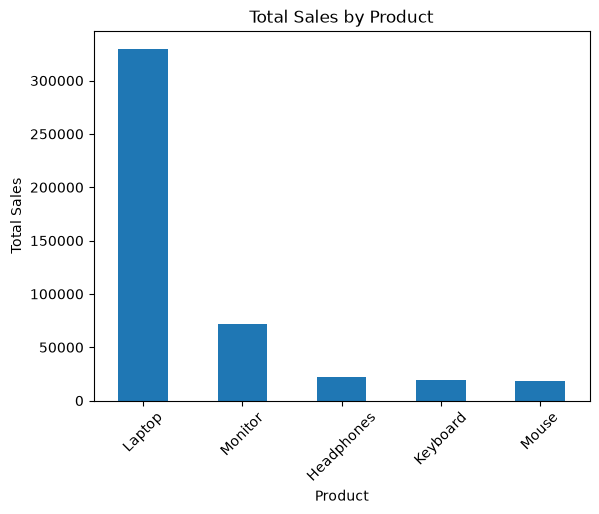

In [24]:
import matplotlib.pyplot as plt

product_sales_sorted.plot(kind="bar")
plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

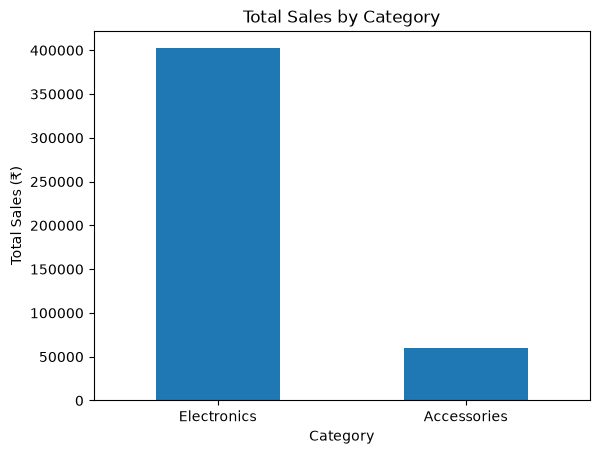

In [25]:
category_sales_sorted.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales (₹)")
plt.xticks(rotation=0)
plt.show()

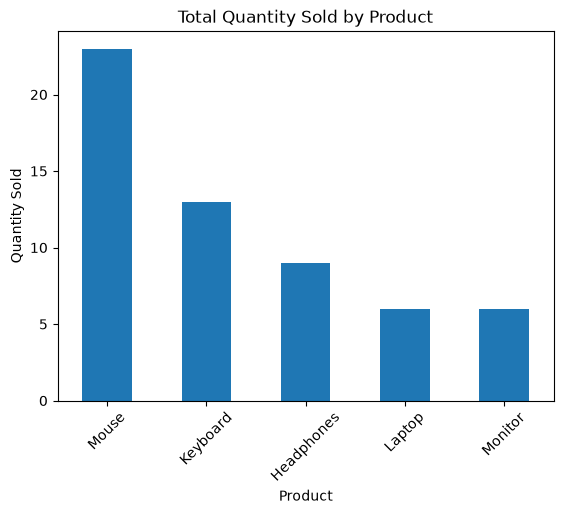

In [26]:
product_quantity_sorted.plot(kind="bar")

plt.title("Total Quantity Sold by Product")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()

In [27]:
product_analysis = df.groupby("Product").agg(
    Total_Quantity=("Quantity", "sum"),
    Total_Sales=("Total_Sales", "sum")
)

product_analysis

,Total_Quantity,Total_Sales
Product,,
Headphones,9,22500
Keyboard,13,19500
Laptop,6,330000
Monitor,6,72000
Mouse,23,18400


In [28]:
product_analysis["Average_Price"] = (
    product_analysis["Total_Sales"] / product_analysis["Total_Quantity"]
)

product_analysis

,Total_Quantity,Total_Sales,Average_Price
Product,,,
Headphones,9,22500,2500.0
Keyboard,13,19500,1500.0
Laptop,6,330000,55000.0
Monitor,6,72000,12000.0
Mouse,23,18400,800.0


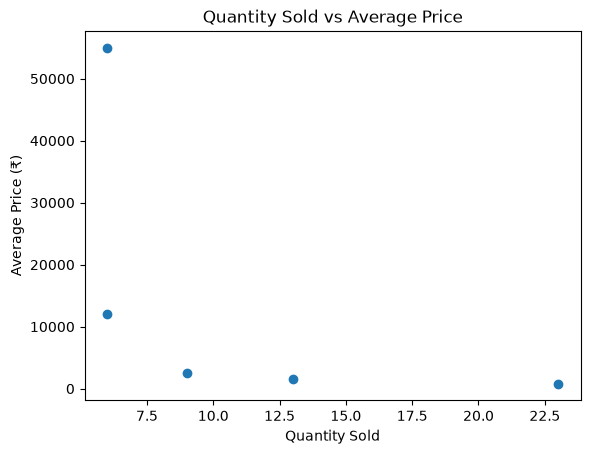

In [29]:
plt.scatter(
    product_analysis["Total_Quantity"],
    product_analysis["Average_Price"]
)

plt.title("Quantity Sold vs Average Price")
plt.xlabel("Quantity Sold")
plt.ylabel("Average Price (₹)")
plt.show()

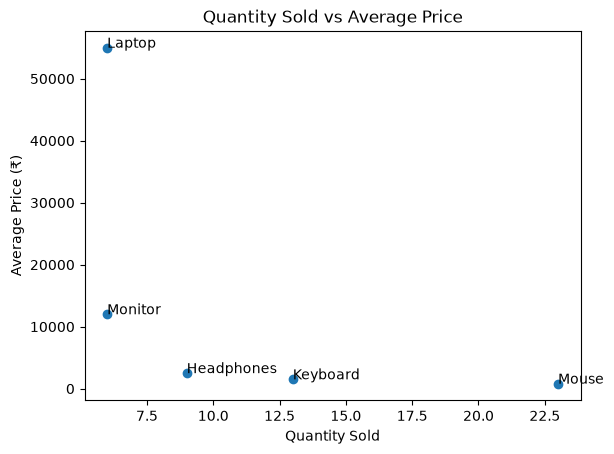

In [30]:
plt.scatter(
    product_analysis["Total_Quantity"],
    product_analysis["Average_Price"]
)

for product in product_analysis.index:
    plt.annotate(
        product,
        (
            product_analysis.loc[product, "Total_Quantity"],
            product_analysis.loc[product, "Average_Price"]
        )
    )

plt.title("Quantity Sold vs Average Price")
plt.xlabel("Quantity Sold")
plt.ylabel("Average Price (₹)")
plt.show()

In [31]:
daily_sales = df.groupby("Date")["Total_Sales"].sum()

daily_sales

Date
2026-01-05    110000
2026-01-06      4000
2026-01-07      4500
2026-01-08     24000
2026-01-09     55000
2026-01-10     10000
2026-01-11      6400
2026-01-12     36000
2026-01-13      9000
2026-01-14    110000
2026-01-15     12500
2026-01-16      8000
2026-01-17     12000
2026-01-18      6000
2026-01-19     55000
Name: Total_Sales, dtype: int64

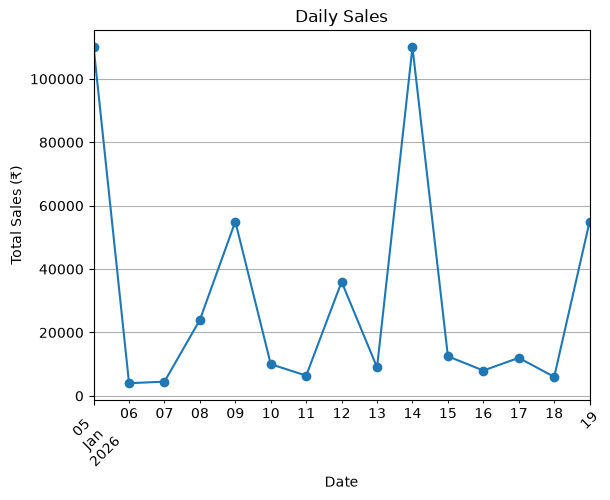

In [32]:
daily_sales.plot(kind="line", marker="o")

plt.title("Daily Sales")
plt.xlabel("Date")
plt.ylabel("Total Sales (₹)")
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [33]:
category_percentage = (
    category_sales / category_sales.sum()
) * 100

category_percentage

Category
Accessories    13.062284
Electronics    86.937716
Name: Total_Sales, dtype: float64

In [34]:
print("PROJECT 02 - PRODUCT PERFORMANCE ANALYSIS")
print("------------------------------------------")

print("1. Highest revenue product: Laptop - ₹3,30,000")
print("2. Highest quantity sold product: Mouse - 23 units")
print("3. Highest revenue category: Electronics - ₹4,02,000")
print("4. Electronics revenue share: 86.94%")
print("5. Accessories revenue share: 13.06%")
print("6. Highest sales days: January 5 and January 14 - ₹1,10,000 each")

PROJECT 02 - PRODUCT PERFORMANCE ANALYSIS
------------------------------------------
1. Highest revenue product: Laptop - ₹3,30,000
2. Highest quantity sold product: Mouse - 23 units
3. Highest revenue category: Electronics - ₹4,02,000
4. Electronics revenue share: 86.94%
5. Accessories revenue share: 13.06%
6. Highest sales days: January 5 and January 14 - ₹1,10,000 each
